Bootstrap imports loaded: 12
Repository root: /content/NATICUSdroid
Imports listos
Resumen del dataset
{'rows': 29332, 'columns': 87, 'feature_columns': 86, 'missing_values': 0, 'class_distribution': {'0': 14632, '1': 14700}, 'class_distribution_percent': {'0': 49.8841, '1': 50.1159}}

Artefactos generados
train_features: /content/NATICUSdroid/data/processed/X_train.csv
test_features: /content/NATICUSdroid/data/processed/X_test.csv
train_target: /content/NATICUSdroid/data/processed/y_train.csv
test_target: /content/NATICUSdroid/data/processed/y_test.csv
train_full: /content/NATICUSdroid/data/processed/train.csv
test_full: /content/NATICUSdroid/data/processed/test.csv
metadata: /content/NATICUSdroid/data/processed/split_metadata.json

X_train shape: (20532, 86)
X_test shape: (8800, 86)
y_train shape: (20532,)
y_test shape: (8800,)
     INICIANDO ANÁLISIS INDIVIDUAL DE VARIABLES (Punto 5.1)

--- RESUMEN DE HALLAZGOS ---
1. Variables con varianza casi nula (casi constantes): 16
2. Variabl

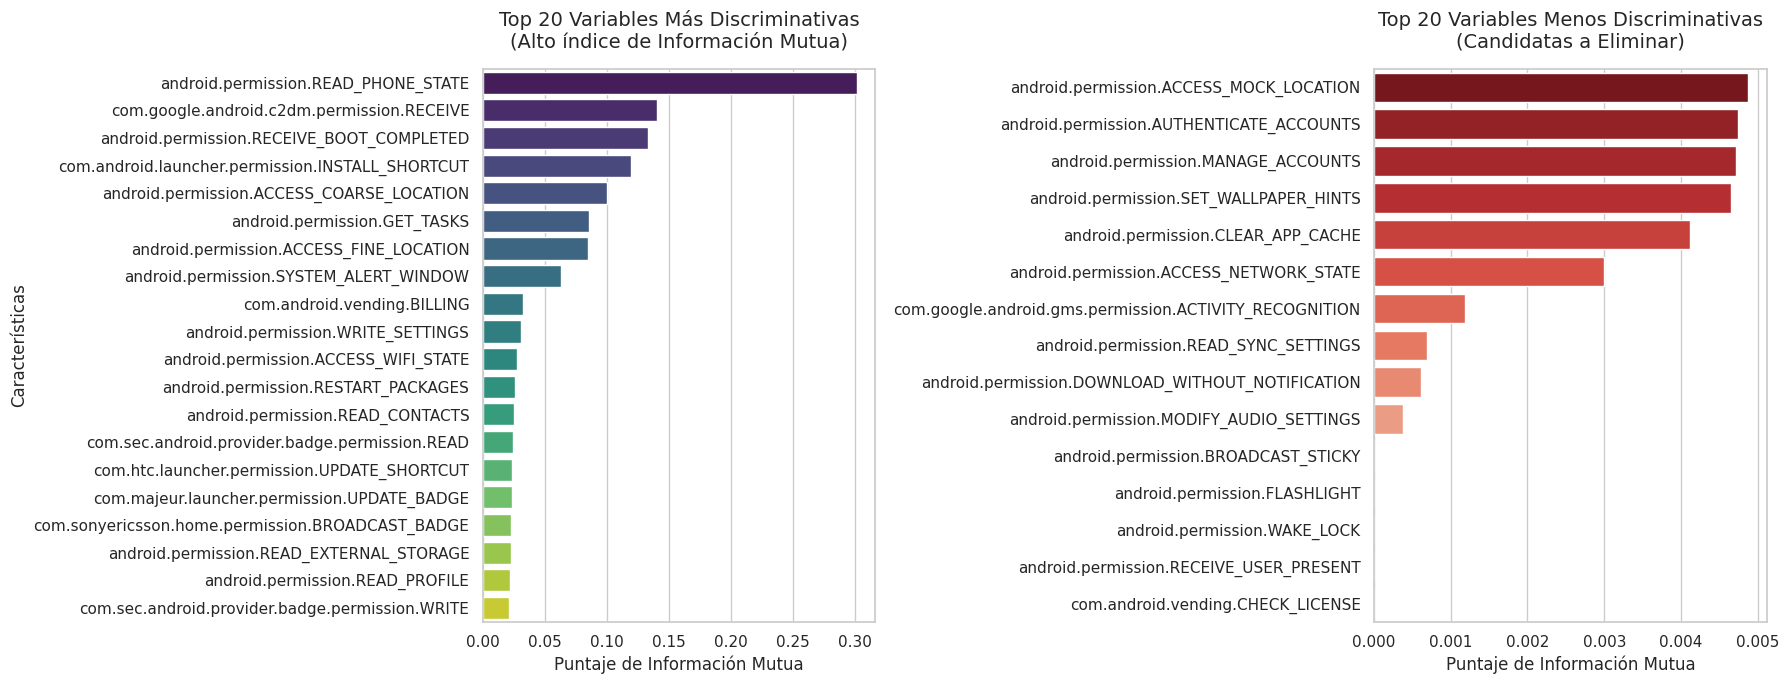

In [3]:
#Lectura data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold

from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/DavidNaranjo1237/NATICUSdroid.git'
REPO_DIR = Path('/content/NATICUSdroid')

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score  # noqa: F401
from sklearn.model_selection import GridSearchCV, StratifiedKFold

_bootstrap_dependencies = (
    np,
    pd,
    RandomForestClassifier,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    GridSearchCV,
    StratifiedKFold,
)
print(f'Bootstrap imports loaded: {len(_bootstrap_dependencies)}')

def is_colab() -> bool:
    return 'COLAB_RELEASE_TAG' in os.environ or 'google.colab' in sys.modules

def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src' / 'prepare_data.py').exists():
            return candidate
    return REPO_DIR if is_colab() else Path.cwd()

repo_root = find_repo_root()
if is_colab() and not (repo_root / 'src' / 'prepare_data.py').exists():
    if not repo_root.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(repo_root)], check=True)
    else:
        print(f'Repository directory already exists at {repo_root}.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'Repository root: {repo_root}')
print('Imports listos')


from src.prepare_data import prepare_dataset

results = prepare_dataset()
summary = results['summary']
artifacts = results['artifacts']
X_train = results['X_train']
X_test = results['X_test']
y_train = results['y_train']
y_test = results['y_test']

print('Resumen del dataset')
print(summary)
print('')
print('Artefactos generados')
for name, value in artifacts.items():
    print(f'{name}: {value}')

print('')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold

# -----------------------------------------------------------------------------
# 1. PREPARACIÓN DE DATOS
# -----------------------------------------------------------------------------
# Asegurar que los datos sean DataFrames de Pandas para manejar los nombres de columnas
if not isinstance(X_train, pd.DataFrame):
    X_train_df = pd.DataFrame(X_train, columns=[f"feature_{i}" for i in range(X_train.shape[1])])
else:
    X_train_df = X_train.copy()

y_train_s = pd.Series(y_train) if not isinstance(y_train, pd.Series) else y_train

print("==========================================================")
print("     INICIANDO ANÁLISIS INDIVIDUAL DE VARIABLES (Punto 5.1)")
print("==========================================================\n")

# -----------------------------------------------------------------------------
# 2. ANÁLISIS DE VARIANZA (Detectar características casi constantes)
# -----------------------------------------------------------------------------
# Un umbral de 0.01 significa que si una variable tiene el mismo valor el 99%
# de las veces, no nos sirve para discriminar.
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_train_df)
con_baja_varianza = X_train_df.columns[~selector_var.get_support()].tolist()

# -----------------------------------------------------------------------------
# 3. CÁLCULO DE CORRELACIÓN DE PEARSON Y MUTUAL INFORMATION
# -----------------------------------------------------------------------------
# Correlación Lineal (Pearson)
df_completo = X_train_df.copy()
df_completo['Result'] = y_train_s.values
correlaciones = df_completo.corr()['Result'].drop('Result')

# Información Mutua (Detecta relaciones no lineales, ideal para MLP y Random Forest)
mi_scores = mutual_info_classif(X_train_df, y_train_s, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_df.columns)

# Consolidar métricas
df_metricas = pd.DataFrame({
    'Correlacion_Absoluta': correlaciones.abs(),
    'Informacion_Mutua': mi_series
}).sort_values(by='Informacion_Mutua', ascending=False)

# Detectar variables sin poder discriminativo (Baja MI y baja correlación)
con_baja_importancia = df_metricas[(df_metricas['Informacion_Mutua'] < 0.005) &
                                   (df_metricas['Correlacion_Absoluta'] < 0.05)].index.tolist()

# -----------------------------------------------------------------------------
# 4. ANÁLISIS DE MULTICOLINEALIDAD (Detectar redundancia entre variables)
# -----------------------------------------------------------------------------
matriz_corr_X = X_train_df.corr().abs()
# Seleccionamos el triángulo superior de la matriz de correlación
triangulo_superior = matriz_corr_X.where(np.triu(np.ones(matriz_corr_X.shape), k=1).astype(bool))
# Variables con más del 85% de correlación entre sí
variables_redundantes = [col for col in triangulo_superior.columns if any(triangulo_superior[col] > 0.85)]

# -----------------------------------------------------------------------------
# 5. CONSOLIDACIÓN DE RESULTADOS Y REPORTE
# -----------------------------------------------------------------------------
candidatas_eliminar = list(set(con_baja_varianza + con_baja_importancia + variables_redundantes))

print("--- RESUMEN DE HALLAZGOS ---")
print(f"1. Variables con varianza casi nula (casi constantes): {len(con_baja_varianza)}")
print(f"2. Variables sin poder discriminativo (Baja Info. Mutua / Correlación): {len(con_baja_importancia)}")
print(f"3. Variables altamente redundantes (Correlación > 85% entre sí): {len(variables_redundantes)}")
print("-" * 58)
print(f"TOTAL DE VARIABLES CANDIDATAS A ELIMINAR: {len(candidatas_eliminar)} de {X_train_df.shape[1]}\n")

print("--- LISTA DETALLADA DE VARIABLES A ELIMINAR ---")
for i, var in enumerate(candidatas_eliminar, 1):
    print(f"{i:02d}. {var}")

# -----------------------------------------------------------------------------
# 6. VISUALIZACIÓN
# -----------------------------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Top 20 Mejores
data_top20 = df_metricas.head(20)
sns.barplot(
    x=data_top20['Informacion_Mutua'],
    y=data_top20.index,
    ax=axes[0],
    hue=data_top20.index,
    palette='viridis',
    legend=False
)
axes[0].set_title("Top 20 Variables Más Discriminativas\n(Alto índice de Información Mutua)", fontsize=14, pad=15)
axes[0].set_xlabel("Puntaje de Información Mutua", fontsize=12)
axes[0].set_ylabel("Características", fontsize=12)

# Gráfico 2: Las Peores (Candidatas a eliminar)
data_peores = df_metricas.loc[df_metricas.index.isin(con_baja_importancia)].tail(20)
sns.barplot(
    x=data_peores['Informacion_Mutua'],
    y=data_peores.index,
    ax=axes[1],
    hue=data_peores.index,
    palette='Reds_r',
    legend=False
)
axes[1].set_title("Top 20 Variables Menos Discriminativas\n(Candidatas a Eliminar)", fontsize=14, pad=15)
axes[1].set_xlabel("Puntaje de Información Mutua", fontsize=12)
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()